# Automotive Feed Data Sanity Analysis

This notebook profiles the full NDJSON feed without changing it or uploading anything. It checks fields, blank values, nested fitment attributes, prices, duplicate IDs, malformed records, and creates visualizations.

In [4]:
from pathlib import Path
import json
from collections import Counter, defaultdict
from itertools import islice

import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

INPUT_PATH = Path('migratedImages_gbi_partNumber_CTNAPAsani_fitment.ndjson')
# For the 10,000-record sample, use:
# INPUT_PATH = Path('migratedImages_gbi_partNumber_CTNAPAsani_fitment_sample_10000.ndjson')

if not INPUT_PATH.exists():
    raise FileNotFoundError(f'Input file not found: {INPUT_PATH.resolve()}')
print(f'Input: {INPUT_PATH.resolve()}')
print(f'Size: {INPUT_PATH.stat().st_size / 1024**2:,.1f} MB')

Input: D:\Rezolve\11-08-2026\graphene_pipeline\migratedImages_gbi_partNumber_CTNAPAsani_fitment.ndjson
Size: 11,606.0 MB


## 1. Load and parse the NDJSON feed

In [5]:
field_present_counts = Counter()
attribute_key_counts = Counter()
attribute_value_counts = defaultdict(Counter)
attribute_records = Counter()
price_values = []
id_counts = Counter()
missing_title_count = 0
malformed_lines = []
preview_records = []
valid_record_count = 0


def is_blank(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    if isinstance(value, str) and not value.strip():
        return True
    if isinstance(value, (list, dict)) and not value:
        return True
    return False


def flattened_fields(record, prefix=''):
    for key, value in record.items():
        field = f'{prefix}.{key}' if prefix else key
        if isinstance(value, dict):
            yield from flattened_fields(value, field)
        else:
            yield field, value


with INPUT_PATH.open(encoding='utf-8') as file:
    for line_number, line in enumerate(file, start=1):
        if not line.strip():
            continue
        try:
            record = json.loads(line)
        except json.JSONDecodeError as error:
            malformed_lines.append({'line': line_number, 'error': str(error)})
            continue

        valid_record_count += 1
        if len(preview_records) < 1000:
            preview_records.append(record)
        if is_blank(record.get('title')):
            missing_title_count += 1
        if not is_blank(record.get('id')):
            id_counts[str(record['id'])] += 1

        for field, value in flattened_fields(record):
            field_present_counts[field] += 1
        price = record.get('priceInfo', {}).get('price')
        if not is_blank(price):
            try:
                price_values.append(float(price))
            except (TypeError, ValueError):
                pass

        for attribute in record.get('attributes', []) or []:
            key = attribute.get('key')
            if not key:
                continue
            attribute_key_counts[key] += 1
            value = attribute.get('value', {})
            text = value.get('text', []) if isinstance(value, dict) else value
            values = text if isinstance(text, list) else [text]
            for item in values:
                if item is not None and str(item).strip():
                    attribute_value_counts[key][str(item)] += 1

        seen_keys = {attribute.get('key') for attribute in record.get('attributes', []) or [] if attribute.get('key')}
        for key in seen_keys:
            attribute_records[key] += 1

records = preview_records
df = pd.json_normalize(records, sep='.')
field_report = pd.DataFrame([
    {'field': field, 'present_count': count}
    for field, count in field_present_counts.items()
])
field_report['blank_count'] = valid_record_count - field_report['present_count']
field_report['blank_pct'] = (field_report['blank_count'] / valid_record_count * 100).round(2)
field_report = field_report.sort_values(['blank_pct', 'field'], ascending=[False, True])
prices = pd.Series(price_values, dtype='float64')

print(f'Valid records: {valid_record_count:,}')
print(f'Malformed records: {len(malformed_lines):,}')
print(f'Columns after normalization (preview): {len(df.columns):,}')
print('Retained only the first 1,000 records for preview; reports use the full feed.')
display(df.head(3))

Valid records: 742,414
Malformed records: 0
Columns after normalization (preview): 16
Retained only the first 1,000 records for preview; reports use the full feed.


,uri,type,name,id,categories,title,images,brands,description,attributes,rating.averageRating,rating.ratingCount,priceInfo.price,priceInfo.originalPrice,availability,availableQuantity
0,https://gb-autoparts.groupby.cloud/product/tit...,PRIMARY,CT_0031702P,CT_0031702P,[Automotive > Tires & Wheels > Tires > Winter ...,CT_0031702P Certified WinterTrek Studdable Tir...,[{'uri': 'https://presales-cdn.rezolve.cloud/a...,[Certified],Special Tread Compound: Winter tread formula a...,"[{'key': 'productWheelType', 'value': {'text':...",4.5321,265,104.99,NaN,NaN,NaN
1,https://gb-autoparts.groupby.cloud/product/tit...,PRIMARY,CT_0042026P,CT_0042026P,[Automotive > Tires & Wheels > Tires > Winter ...,CT_0042026P Dynamo DW701 Tire,[{'uri': 'https://presales-cdn.rezolve.cloud/a...,[Dynamo],Dynamo DW701 Tire features a tread pattern wit...,"[{'key': 'productWheelType', 'value': {'text':...",4.2890,173,88.99,NaN,NaN,NaN
2,https://gb-autoparts.groupby.cloud/product/tit...,PRIMARY,CT_0042034P,CT_0042034P,[Automotive > Tires & Wheels > Tires > All Sea...,CT_0042034P General Evertrek GT All Season Tir...,[{'uri': 'https://presales-cdn.rezolve.cloud/a...,[General Tire],Pattern void updates improving wet handling an...,"[{'key': 'productWheelType', 'value': {'text':...",4.5707,205,139.99,NaN,NaN,NaN


## 2. Top-level field presence and blank percentages

In [6]:
display(field_report)

,field,present_count,blank_count,blank_pct
13,priceInfo.originalPrice,1210,741204,99.84
2,name,10026,732388,98.65
8,rating.averageRating,10026,732388,98.65
9,rating.ratingCount,10026,732388,98.65
18,materials,13816,728598,98.14
16,tags,193539,548875,73.93
7,brands,721534,20880,2.81
17,fulfillmentInfo,732388,10026,1.35
14,availability,741440,974,0.13
15,availableQuantity,741440,974,0.13


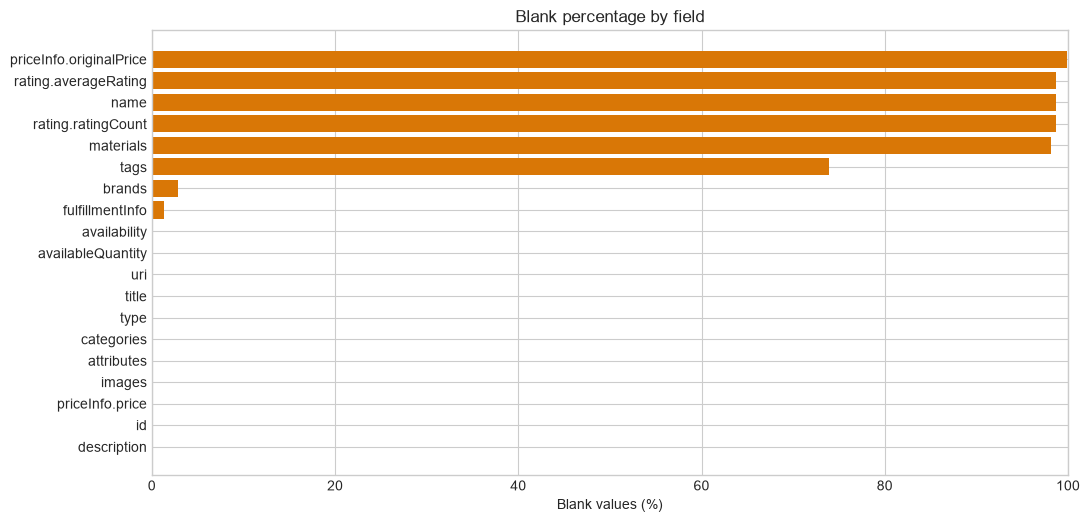

In [7]:
plot_data = field_report.sort_values('blank_pct', ascending=True)
plt.figure(figsize=(11, max(5, len(plot_data) * 0.28)))
plt.barh(plot_data['field'], plot_data['blank_pct'], color='#d97706')
plt.xlabel('Blank values (%)')
plt.title('Blank percentage by field')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 3. Nested fitment attribute analysis

In [8]:
attribute_key_counts = Counter()
attribute_value_counts = defaultdict(Counter)
attribute_records = Counter()

for record in records:
    seen_keys = set()
    for attribute in record.get('attributes', []) or []:
        key = attribute.get('key')
        if not key:
            continue
        attribute_key_counts[key] += 1
        seen_keys.add(key)
        value = attribute.get('value', {})
        text = value.get('text', []) if isinstance(value, dict) else value
        values = text if isinstance(text, list) else [text]
        for item in values:
            if item is not None and str(item).strip():
                attribute_value_counts[key][str(item)] += 1
    for key in seen_keys:
        attribute_records[key] += 1

attribute_report = pd.DataFrame([
    {'attribute_key': key, 'records_with_key': attribute_records[key], 'occurrences': count, 'presence_pct': round(attribute_records[key] / len(records) * 100, 2), 'unique_values': len(attribute_value_counts[key])}
    for key, count in attribute_key_counts.items()
]).sort_values('presence_pct', ascending=False)
display(attribute_report)

,attribute_key,records_with_key,occurrences,presence_pct,unique_values
1,sellable,1000,1000,100.0,1
2,orderable,1000,1000,100.0,2
3,lowStockThreshold,1000,1000,100.0,0
4,at_universal,1000,1000,100.0,1
6,siteid,1000,1000,100.0,1
5,guaranteed_fit_1,1000,1000,100.0,1
7,gbi_L1,1000,1000,100.0,5
8,gbi_L2,1000,1000,100.0,40
11,partNumber_search,1000,1000,100.0,3146
9,gbi_L3,1000,1000,100.0,117


In [9]:
for key in ['ymm_1', 'ymm_2', 'all_all_all']:
    if key in attribute_value_counts:
        print(f'Values for attribute key: {key}')
        display(pd.DataFrame(attribute_value_counts[key].most_common(20), columns=['value', 'count']))

ymm_values = Counter()
for key in ('ymm_1', 'ymm_2'):
    ymm_values.update(attribute_value_counts[key])
if ymm_values:
    top_ymm = pd.DataFrame(ymm_values.most_common(20), columns=['fitment_value', 'count'])
    plt.figure(figsize=(10, 6))
    plt.barh(top_ymm['fitment_value'][::-1], top_ymm['count'][::-1], color='#2563eb')
    plt.title('Most common YMM fitment values')
    plt.xlabel('Occurrences')
    plt.tight_layout()
    plt.show()

## 4. Price analysis

In [10]:
prices = pd.to_numeric(df.get('priceInfo.price', pd.Series(dtype='float64')), errors='coerce')
price_report = pd.DataFrame({'price': prices}).dropna()
price_report['price_band'] = pd.cut(
    price_report['price'],
    bins=[-float('inf'), 0, 10, 25, 50, 100, 250, 500, 1000, float('inf')],
    labels=['<= 0', '0-10', '10-25', '25-50', '50-100', '100-250', '250-500', '500-1000', '> 1000']
)
print(f'Non-blank prices: {len(price_report):,} / {len(df):,}')
display(price_report['price'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)
display(price_report['price_band'].value_counts(sort=False).rename('count').to_frame())

Non-blank prices: 1,000 / 1,000


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,1000.0,178.57212,226.716269,2.99,4.99,12.99,49.99,114.99,231.24,549.99,1079.2,2199.99


,count
price_band,
<= 0,0
0-10,38
10-25,111
25-50,113
50-100,221
100-250,315
250-500,145
500-1000,45
> 1000,12


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'x' with shape (8,) and 'height' with shape (9,).

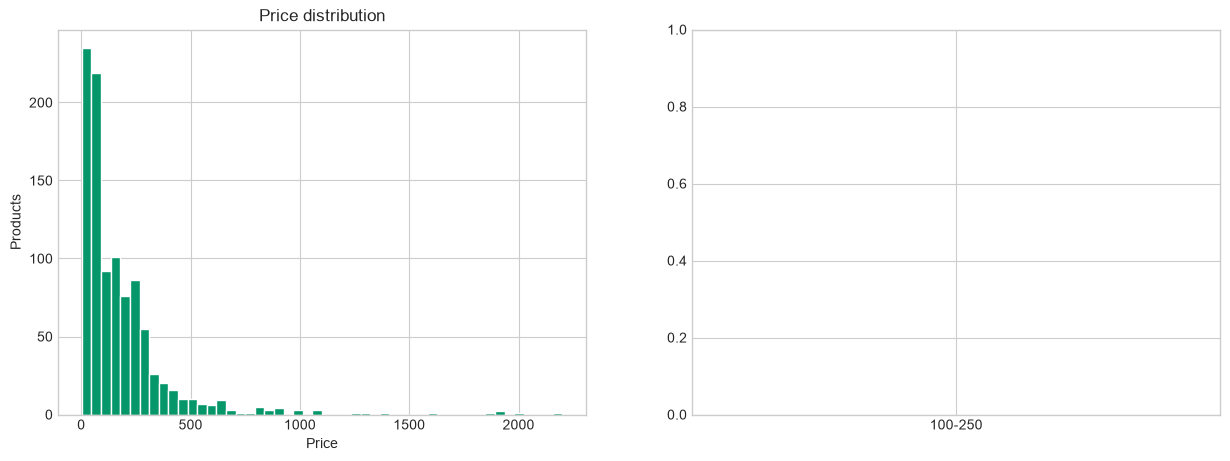

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(price_report['price'].clip(lower=0), bins=50, color='#059669', edgecolor='white')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Products')
axes[1].bar(price_report['price_band'].astype(str).value_counts(sort=False).index, price_report['price_band'].value_counts(sort=False).values, color='#7c3aed')
axes[1].set_title('Products by price band')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Sanity checks

In [ ]:
ids = df.get('id', pd.Series(dtype='object'))
sanity_checks = pd.DataFrame([
    {'check': 'Total valid records', 'count': len(records)},
    {'check': 'Malformed non-empty lines', 'count': len(malformed_lines)},
    {'check': 'Missing IDs', 'count': sum(is_blank(v) for v in ids)},
    {'check': 'Duplicate IDs', 'count': int(ids.dropna().duplicated().sum())},
    {'check': 'Missing titles', 'count': sum(is_blank(v) for v in df.get('title', pd.Series(dtype='object')))},
    {'check': 'Missing prices', 'count': int(prices.isna().sum())},
    {'check': 'Non-positive prices', 'count': int((prices <= 0).sum())},
    {'check': 'Negative prices', 'count': int((prices < 0).sum())},
])
display(sanity_checks)

duplicate_ids = ids[ids.duplicated(keep=False)].dropna().unique().tolist()
if duplicate_ids:
    print('Example duplicate IDs:', duplicate_ids[:20])
if malformed_lines:
    display(pd.DataFrame(malformed_lines).head(20))

## 6. Export reports

The following cell writes summary CSV reports next to the notebook. It does not modify the source feed.

In [ ]:
REPORT_DIR = Path('analysis_reports')
REPORT_DIR.mkdir(exist_ok=True)
field_report.to_csv(REPORT_DIR / 'field_presence_report.csv', index=False)
attribute_report.to_csv(REPORT_DIR / 'attribute_presence_report.csv', index=False)
price_report.to_csv(REPORT_DIR / 'price_report.csv', index=False)
sanity_checks.to_csv(REPORT_DIR / 'sanity_checks.csv', index=False)
print(f'Reports written to {REPORT_DIR.resolve()}')